# Train a crop-level accessibility-violation classifier

**Goal:** train a small CV classifier that looks at a *cropped region* of a
screenshot (not the full screen) and predicts which of a fixed set of
accessibility rules that region violates. This is **Task B** from
`model-comparison-cv-training (1).docx` ("Crop Classification") — a
different job from the existing YOLO detector
(`notebooks/train_yolo_ui_detector.ipynb`, **Task A**), which only *locates*
UI elements on the full screenshot.

## Why this model exists at all

`docs/user_coverage_for_training.md` splits the 30 accessibility rules into
two buckets:

- Most rules (R01, R02, R03, R05, R06, R12, R13, R15, R16, R19-R27, R29,
  R30, ...) are **already fully solved by the XML parser + rule checker**
  (`src/rules.py`) — they read `text`, `content-desc`, `clickable`, `bounds`
  straight from the UI hierarchy. No model needed.
- A handful of rules need to look at the **rendered pixels**, not just the
  XML, because the thing that makes them a violation (a color contrast
  ratio, clipped/overlapping text, a screen-density-relative touch target)
  only exists once the layout is rendered:

| Rule | Violation | Why it needs pixels |
|---|---|---|
| **R09** | Low contrast (text/background ratio) | Needs actual foreground/background pixel colors |
| **R04** | Small touch target (< 48dp) | XML gives raw bounds; a visual crop confirms real on-screen tap size |
| **R17** | Insufficient spacing between clickable elements (< 8dp) | Same — visual crop confirms actual rendered gap |
| **R10** | Text overflow (text taller than its box) | Needs to see if rendered text is visually clipped |
| **R28** | Font-scale overflow (200% scale wouldn't fit) | Same — visual confirmation of clipping |
| **R08** | Layout overlap between elements | Bounding-box math catches some cases; a crop reduces false positives |

This notebook builds a **multi-label crop classifier** over exactly these 6
rules: given a crop, predict which (if any) of `[R09, R04, R17, R10, R28,
R08]` apply. A crop can trigger more than one rule at once (e.g. a button
that is both too small *and* too close to its neighbor), hence multi-label
rather than a single softmax over classes.

## Backbone

`build_model()` (below) supports 35 ImageNet-pretrained backbones via a single switch,
`CFG["backbone"]` - everything from lightweight MobileNet-family models through ResNet-50,
EfficientNet, ViT-B/16, and MobileViT. Full architecture background for every one of them
(year, paper, design, why it was included) is in `docs/crop_classifier_model_reference.md`.

**Current default: `mobilenet_v3_small`** - the original pick per `docs/picking_model_for_crop.md`,
kept as the config default. Actual comparison results across all 33 backbones (params, MASC test
F1, Rico holdout generalization F1, per-rule breakdowns) are in
`docs/crop_classifier_comparison_findings.md` - see that doc for which backbone the data actually
supports as the best pick, not just the a priori reasoning below.


## 0. Environment setup

Checks that `torch`, `torchvision` and the other packages this notebook
needs are importable, installing anything missing.

In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = [
    ("torch", "torch"),
    ("torchvision", "torchvision"),
    ("PIL", "Pillow"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("sklearn", "scikit-learn"),
    ("lxml", "lxml>=5.2.0"),
]

missing = []
for import_name, pip_spec in REQUIRED_PACKAGES:
    try:
        importlib.import_module(import_name)
    except ImportError:
        missing.append(pip_spec)

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("All required packages already importable.")

import torch
import torchvision
print(f"torch {torch.__version__}, torchvision {torchvision.__version__}")


All required packages already importable.
torch 2.5.1+cu121, torchvision 0.20.1+cu121


## Config

Every path and hyperparameter used below lives in one place: `CFG`. Flip
`LOCAL_MODE` to `True` (the default) to run a fast smoke test on a handful
of screens (works on CPU) - useful for catching bugs in the crop-extraction
/ dataset-building logic before committing to a full training run; `False`
runs the real pipeline on the full `data-masc` split.

`REPO_ROOT` is auto-discovered by walking up from the notebook's working
directory looking for a folder that contains both `src/` and `data/` -
this works whether you launched Jupyter from the repo root or from
`notebooks/`. `OUTPUT_ROOT` is a local directory
(`<repo>/runs/crop_violation_classifier` by default) that holds the
generated crop images, manifests, checkpoints and exports - it's
gitignored, so re-running the notebook never risks committing large
binaries.

In [2]:
import sys
from pathlib import Path


def find_repo_root(start: Path):
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    return None


def discover_repo_root() -> Path:
    detected = globals().get("DETECTED_REPO_ROOT")
    if detected is not None and Path(detected).is_dir():
        p = Path(detected)
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p

    REPO_ROOT_OVERRIDE = None  # e.g. Path("/content/_noor_push")
    if REPO_ROOT_OVERRIDE is not None:
        p = Path(REPO_ROOT_OVERRIDE)
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p

    found = find_repo_root(Path.cwd())
    if found is not None:
        return found

    for root in (Path("/content"), Path("/content/drive/MyDrive")):
        if not root.exists():
            continue
        if (root / "src").is_dir() and (root / "data").is_dir():
            return root
        try:
            for child in root.iterdir():
                if (child / "src").is_dir() and (child / "data").is_dir():
                    return child
        except PermissionError:
            pass

    raise RuntimeError(
        "Could not find repo root (folder with both src/ and data/). "
        "Run the Colab setup cell first, or set REPO_ROOT_OVERRIDE in this cell."
    )


LOCAL_MODE = False  # <-- flip to False for the full training run

REPO_ROOT = discover_repo_root()
if Path.cwd().resolve() != REPO_ROOT.resolve():
    import os
    os.chdir(REPO_ROOT)
    print(f"chdir -> {REPO_ROOT}")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_ROOT = REPO_ROOT / "runs" / "crop_violation_classifier"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DATA_ROOT = REPO_ROOT / "data"

CFG = {
    "local_mode": LOCAL_MODE,
    "repo_root": REPO_ROOT,
    "output_root": OUTPUT_ROOT,
    "data_root": DATA_ROOT,
    "masc_root": DATA_ROOT / "data-masc",
    "splits_dir": DATA_ROOT / "data-masc" / "splits",
    "crop_dir": OUTPUT_ROOT / "crops",
    "manifest_dir": OUTPUT_ROOT / "manifests",
    "runs_dir": OUTPUT_ROOT / "runs",
    "export_dir": OUTPUT_ROOT / "export",
    "run_name": "crop_violation_classifier_mobilevitv2_200",

    # -- rule taxonomy: order fixes the label-vector index for every rule --
    # see docs/user_coverage_for_training.md + docs/accessibility_guidelines_report.md
    "rule_classes": ["R09", "R04", "R17", "R10", "R28", "R08"],
    "rule_descriptions": {
        "R09": "Low contrast (text/background ratio)",
        "R04": "Small touch target (< 48dp)",
        "R17": "Insufficient spacing between clickable elements (< 8dp)",
        "R10": "Text overflow (text taller than its box)",
        "R28": "Font-scale overflow (200% scale wouldn't fit)",
        "R08": "Layout overlap between elements",
    },

    # -- crop extraction --
    "crop_size": 224,          # input resolution fed to the backbone
    "context_pad_frac": 0.15,  # extra context around each element's bounds
    "min_crop_px": 8,          # skip degenerate/near-zero-area crops
    "negatives_per_screen": 3, # non-violating clickable/text elements sampled per screen

    # -- model --
    "backbone": "mobilevitv2_200",  # 33 valid options - see "## 5. Model" markdown cell below for the full list
    "pretrained": True,
    "freeze_backbone_epochs": 3,

    # -- training --
    "epochs": 20,
    "batch_size": 32,
    "lr": 1e-3,
    "finetune_lr": 1e-4,
    "patience": 5,
    "seed": 42,
    "pred_threshold": 0.5,

    "local_smoke_n": 25,  # screens per split when LOCAL_MODE=True
}

for key in ("masc_root", "splits_dir"):
    print(f"{key:14s} -> {CFG[key]} (exists: {CFG[key].exists()})")
print(f"{'output_root':14s} -> {OUTPUT_ROOT}")
print(f"{'LOCAL_MODE':14s} -> {LOCAL_MODE}")
print(f"{'REPO_ROOT':14s} -> {REPO_ROOT}")
print(f"{'backbone':14s} -> {CFG['backbone']}")


masc_root      -> C:\Users\Lab\agentic-accessibility-auditor\data\data-masc (exists: True)
splits_dir     -> C:\Users\Lab\agentic-accessibility-auditor\data\data-masc\splits (exists: True)
output_root    -> C:\Users\Lab\agentic-accessibility-auditor\runs\crop_violation_classifier
LOCAL_MODE     -> False
REPO_ROOT      -> C:\Users\Lab\agentic-accessibility-auditor
backbone       -> mobilevitv2_200


## Verify the data layout matches what this notebook assumes

Before touching any crop-extraction logic, confirm the directories and
split CSVs this notebook reads from are actually present. Same
`data-masc` splits the YOLO detector notebook uses
(`data/data-masc/splits/{train,val,test}.csv`), so both notebooks stay
consistent about what "train/val/test" means.

In [3]:
if "CFG" not in globals():
    raise RuntimeError(
        "CFG is not defined - the Config cell failed or was skipped. "
        "Run the Colab setup cell, then the Config cell, then this cell."
    )

import csv

masc_root = CFG["masc_root"]
splits_dir = CFG["splits_dir"]

checks = {
    "data-masc/screenshots": masc_root / "screenshots",
    "data-masc/xml": masc_root / "xml",
    "data-masc/splits/train.csv": splits_dir / "train.csv",
    "data-masc/splits/val.csv": splits_dir / "val.csv",
    "data-masc/splits/test.csv": splits_dir / "test.csv",
}

ok = True
for label, path in checks.items():
    exists = path.exists()
    ok &= exists
    print(f"[{'OK' if exists else 'MISSING'}] {label} -> {path}")

if not ok:
    raise FileNotFoundError(
        "One or more required data-masc paths are missing under DATA_ROOT "
        f"({DATA_ROOT}). Check that data-masc is present in this repo's data/ dir."
    )

split_rows = {}
for split_name in ("train", "val", "test"):
    with open(splits_dir / f"{split_name}.csv", newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    split_rows[split_name] = rows
    print(f"{split_name}: {len(rows)} rows, columns={list(rows[0].keys())}")


[OK] data-masc/screenshots -> C:\Users\Lab\agentic-accessibility-auditor\data\data-masc\screenshots
[OK] data-masc/xml -> C:\Users\Lab\agentic-accessibility-auditor\data\data-masc\xml
[OK] data-masc/splits/train.csv -> C:\Users\Lab\agentic-accessibility-auditor\data\data-masc\splits\train.csv
[OK] data-masc/splits/val.csv -> C:\Users\Lab\agentic-accessibility-auditor\data\data-masc\splits\val.csv
[OK] data-masc/splits/test.csv -> C:\Users\Lab\agentic-accessibility-auditor\data\data-masc\splits\test.csv
train: 4943 rows, columns=['screen_id', 'class', 'category', 'image_path', 'xml_path']
val: 1056 rows, columns=['screen_id', 'class', 'category', 'image_path', 'xml_path']
test: 1069 rows, columns=['screen_id', 'class', 'category', 'image_path', 'xml_path']


## 1. Rule-violation detection per screen

Reuses the existing, already-tested rule checker (`src/rules.py`) instead
of re-implementing contrast/overlap/spacing math here. For each screen we:

1. Parse the XML into a `components.json`-shaped doc via
   `src.parser.build_screen_document` (same helper the YOLO notebook uses).
2. Run `src.rules.check(doc)` to get every violation on that screen.
3. Keep only violations whose `rule_id` is one of our 6 target rules.

This gives us, per screen, a mapping from `component_id` -> set of target
rules it violates - everything needed to build positive crops.

In [4]:
from src.parser import build_screen_document
from src.rules import check as run_rule_checks

RULE_CLASSES = CFG["rule_classes"]


def target_violations_by_component(doc):
    '''Run the full rule checker and keep only our 6 target rules.

    Returns {component_id: set(rule_id)} for every component flagged by at
    least one of RULE_CLASSES.
    '''
    violations = run_rule_checks(doc)["violations"]
    hits = {}
    for v in violations:
        if v["rule_id"] in RULE_CLASSES:
            hits.setdefault(v["component_id"], set()).add(v["rule_id"])
    return hits


print("Loaded target_violations_by_component(). Target rules:", RULE_CLASSES)


Loaded target_violations_by_component(). Target rules: ['R09', 'R04', 'R17', 'R10', 'R28', 'R08']


## 2. Crop extraction

XML `bounds` live in the XML's own canvas coordinate space, which isn't
always the same size as the saved screenshot (different device density,
downscaled screenshots, etc.) - so bounds must be scaled into actual image
pixel space before cropping, exactly like the YOLO notebook's
`convert_screen_to_yolo_labels` does for bounding boxes. We reuse the same
"origin-anchored components define the real canvas" trick, since the XML
root itself carries no reliable `bounds` attribute in this dataset.

For every screen we build:
- **Positive crops** - one per component flagged by >=1 target rule, label
  = multi-hot vector over which of the 6 rules it triggered.
- **Negative crops** - up to `CFG["negatives_per_screen"]` clickable/text
  elements on the same screen that were *not* flagged by any target rule,
  label = all-zero vector.

In [5]:
import random
from collections import Counter

from PIL import Image


def _xml_canvas_size(device_info, components):
    # See notebooks/train_yolo_ui_detector.ipynb for the full rationale:
    # device_info can be inflated by off-canvas siblings (e.g. inactive
    # ViewPager pages), so we trust the union of origin-anchored ((0,0)-left)
    # components first, since real full-screen root containers are always
    # anchored at the origin.
    origin_anchored = [c for c in components if c["bounds"][0] == 0 and c["bounds"][1] == 0]
    w = max((c["bounds"][2] for c in origin_anchored), default=0)
    h = max((c["bounds"][3] for c in origin_anchored), default=0)
    if w > 0 and h > 0:
        return w, h
    w = device_info.get("width_px", 0) or 0
    h = device_info.get("height_px", 0) or 0
    if w > 0 and h > 0:
        return w, h
    w = max((c["bounds"][2] for c in components), default=0)
    h = max((c["bounds"][3] for c in components), default=0)
    return w, h


def _scaled_padded_box(bounds, scale_x, scale_y, img_w, img_h, pad_frac, min_px):
    left, top, right, bottom = bounds
    left, right = left * scale_x, right * scale_x
    top, bottom = top * scale_y, bottom * scale_y
    if right - left < min_px or bottom - top < min_px:
        return None

    pad_x = (right - left) * pad_frac
    pad_y = (bottom - top) * pad_frac
    left, right = left - pad_x, right + pad_x
    top, bottom = top - pad_y, bottom + pad_y

    left = max(0.0, min(left, img_w))
    right = max(0.0, min(right, img_w))
    top = max(0.0, min(top, img_h))
    bottom = max(0.0, min(bottom, img_h))

    if right - left < min_px or bottom - top < min_px:
        return None
    return (int(left), int(top), int(right), int(bottom))


def extract_screen_records(xml_path, image_path, rng):
    '''Parse one screen, run the rule checker, and return crop records.

    Each record: {"bounds": (l,t,r,b) in image-pixel space, "label": list[int]
    (multi-hot over RULE_CLASSES), "class": android widget class,
    "component_id": str}. Does not touch disk - crops are cut out later.
    '''
    doc = build_screen_document(xml_path, CFG["masc_root"] / "xml", CFG["masc_root"])
    components = [c for c in doc["components"] if c.get("visible", True)]
    if not components:
        return []

    device_info = doc["device_info"]
    with Image.open(image_path) as im:
        img_w, img_h = im.size

    xml_w, xml_h = _xml_canvas_size(device_info, components)
    if xml_w <= 0 or xml_h <= 0:
        return []
    scale_x, scale_y = img_w / xml_w, img_h / xml_h

    hits = target_violations_by_component(doc)
    comps_by_id = {c["component_id"]: c for c in components}

    records = []
    for comp_id, rules_hit in hits.items():
        comp = comps_by_id.get(comp_id)
        if comp is None:
            continue
        box = _scaled_padded_box(
            comp["bounds"], scale_x, scale_y, img_w, img_h,
            CFG["context_pad_frac"], CFG["min_crop_px"],
        )
        if box is None:
            continue
        label = [1 if r in rules_hit else 0 for r in RULE_CLASSES]
        records.append({
            "component_id": comp_id, "bounds": box, "label": label,
            "class": comp["class"], "is_positive": True,
        })

    candidates = [
        c for c in components
        if c["component_id"] not in hits and (c["clickable"] or c["text"])
    ]
    rng.shuffle(candidates)
    n_neg = 0
    for comp in candidates:
        if n_neg >= CFG["negatives_per_screen"]:
            break
        box = _scaled_padded_box(
            comp["bounds"], scale_x, scale_y, img_w, img_h,
            CFG["context_pad_frac"], CFG["min_crop_px"],
        )
        if box is None:
            continue
        records.append({
            "component_id": comp["component_id"], "bounds": box,
            "label": [0] * len(RULE_CLASSES), "class": comp["class"],
            "is_positive": False,
        })
        n_neg += 1

    return records


print("Loaded extract_screen_records().")


Loaded extract_screen_records().


## Build the crop dataset + manifests

Crops are cut from the source screenshots, resized to `CFG["crop_size"]`,
and written under `OUTPUT_ROOT/crops/{split}/`. A manifest CSV per split
(`OUTPUT_ROOT/manifests/{split}.csv`) records the crop path, its multi-hot
label, and bookkeeping columns (`screen_id`, `component_id`, `class`,
`is_positive`) for later inspection.

`LOCAL_MODE=True` limits each split to `CFG["local_smoke_n"]` screens so
this cell finishes in well under a minute on CPU.

In [6]:
import shutil

random.seed(CFG["seed"])

for d in (CFG["crop_dir"], CFG["manifest_dir"]):
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

build_summaries = {}

for split_name, rows in split_rows.items():
    if CFG["local_mode"]:
        rows = rows[: CFG["local_smoke_n"]]

    split_crop_dir = CFG["crop_dir"] / split_name
    split_crop_dir.mkdir(parents=True, exist_ok=True)

    rng = random.Random(CFG["seed"])
    manifest_rows = []
    label_counts = Counter()
    n_positive_crops = 0
    n_negative_crops = 0
    n_screens_skipped = 0

    for row in rows:
        xml_path = CFG["repo_root"] / row["xml_path"]
        image_path = CFG["repo_root"] / row["image_path"]
        if not xml_path.exists() or not image_path.exists():
            n_screens_skipped += 1
            continue

        try:
            records = extract_screen_records(xml_path, image_path, rng)
        except Exception as exc:
            print(f"[skip] {row['screen_id']} ({row['category']}): {exc}")
            n_screens_skipped += 1
            continue

        if not records:
            continue

        with Image.open(image_path) as im:
            im = im.convert("RGB")
            for i, rec in enumerate(records):
                crop = im.crop(rec["bounds"]).resize(
                    (CFG["crop_size"], CFG["crop_size"]), Image.BILINEAR
                )
                crop_name = f"{row['category']}_{row['screen_id']}_{rec['component_id']}.png"
                crop_path = split_crop_dir / crop_name
                crop.save(crop_path)

                manifest_rows.append({
                    "crop_path": str(crop_path.relative_to(CFG["output_root"])),
                    "screen_id": row["screen_id"], "category": row["category"],
                    "component_id": rec["component_id"], "class": rec["class"],
                    "is_positive": rec["is_positive"],
                    **{rule: label_val for rule, label_val in zip(RULE_CLASSES, rec["label"])},
                })
                if rec["is_positive"]:
                    n_positive_crops += 1
                    for rule, label_val in zip(RULE_CLASSES, rec["label"]):
                        if label_val:
                            label_counts[rule] += 1
                else:
                    n_negative_crops += 1

    manifest_path = CFG["manifest_dir"] / f"{split_name}.csv"
    with open(manifest_path, "w", newline="", encoding="utf-8") as f:
        fieldnames = ["crop_path", "screen_id", "category", "component_id", "class", "is_positive", *RULE_CLASSES]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(manifest_rows)

    build_summaries[split_name] = {
        "n_screens": len(rows), "n_screens_skipped": n_screens_skipped,
        "n_crops": len(manifest_rows), "n_positive": n_positive_crops,
        "n_negative": n_negative_crops, "label_counts": dict(label_counts),
    }
    print(f"[{split_name}] {len(manifest_rows)} crops from {len(rows) - n_screens_skipped}/{len(rows)} screens "
          f"({n_positive_crops} positive, {n_negative_crops} negative) -> {manifest_path}")
    print(f"           per-rule positive counts: {dict(label_counts)}")

if build_summaries["train"]["n_crops"] == 0:
    raise RuntimeError("No training crops were generated - check the data layout and rule checker output above.")


[train] 25202 crops from 4943/4943 screens (10549 positive, 14653 negative) -> C:\Users\Lab\agentic-accessibility-auditor\runs\crop_violation_classifier\manifests\train.csv
           per-rule positive counts: {'R08': 8089, 'R04': 288, 'R17': 2879}


[val] 5558 crops from 1056/1056 screens (2433 positive, 3125 negative) -> C:\Users\Lab\agentic-accessibility-auditor\runs\crop_violation_classifier\manifests\val.csv
           per-rule positive counts: {'R08': 1921, 'R17': 641, 'R10': 1, 'R04': 39}


[test] 5541 crops from 1069/1069 screens (2367 positive, 3174 negative) -> C:\Users\Lab\agentic-accessibility-auditor\runs\crop_violation_classifier\manifests\test.csv
           per-rule positive counts: {'R08': 1805, 'R17': 660, 'R04': 45}


## 3. Sanity-check cell (mandatory before training)

Render a grid of crops from the training manifest with their multi-hot
labels overlaid as a title. Positive crops (any rule = 1) get a red border,
negatives a green one. Run this **every time** the extraction cell above
changes - a wrong scale factor or an off-by-one in the padding silently
produces garbage crops that still "train" without erroring.

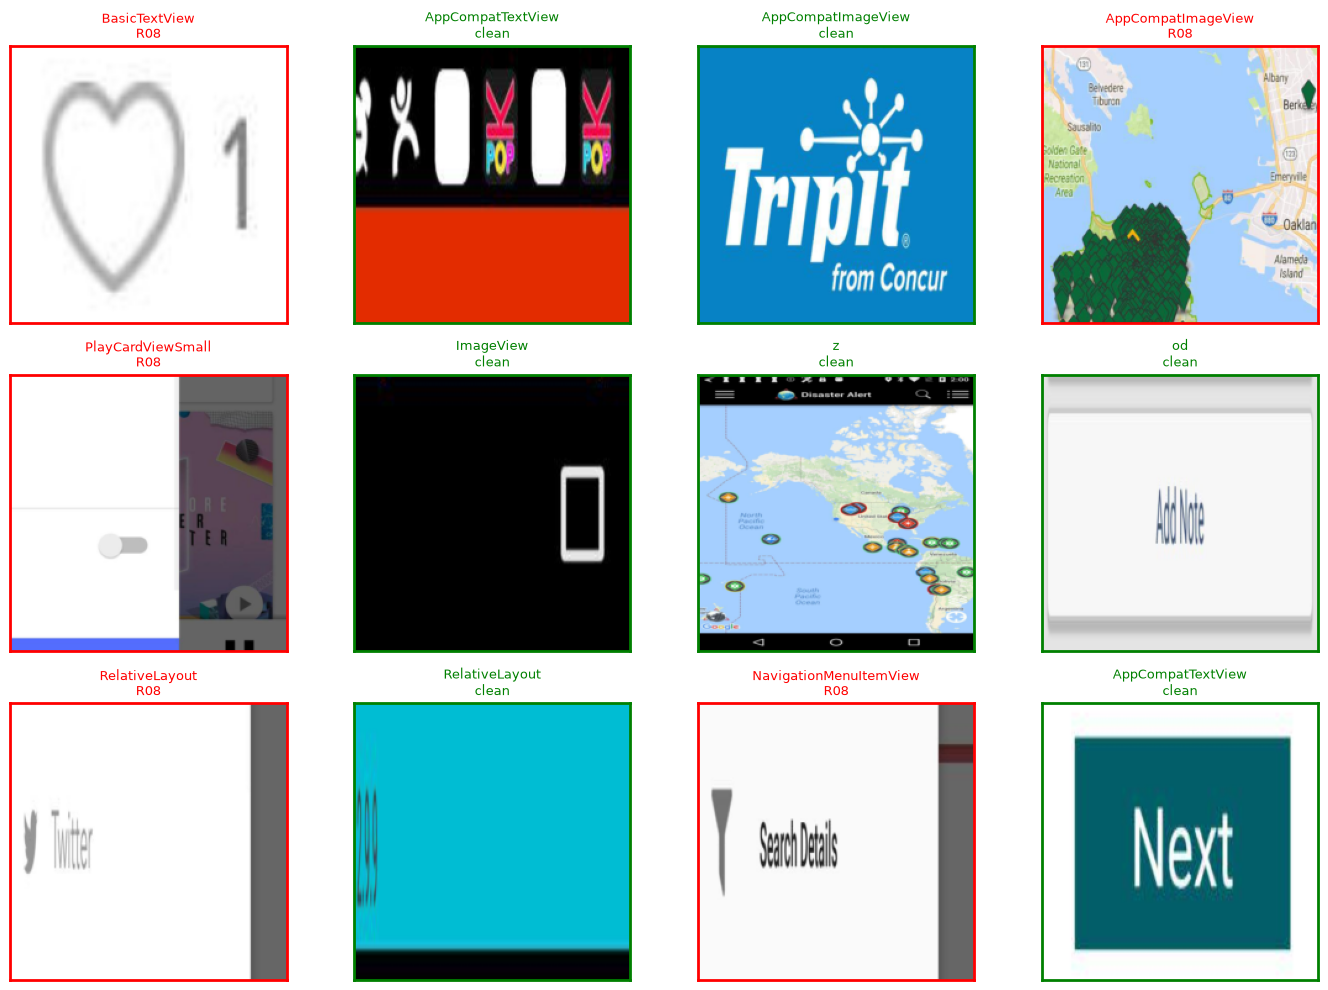

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

train_manifest = pd.read_csv(CFG["manifest_dir"] / "train.csv")

sample_n = min(12, len(train_manifest))
sample = train_manifest.sample(n=sample_n, random_state=CFG["seed"]) if sample_n else train_manifest

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(CFG["output_root"] / row["crop_path"])
    ax.imshow(img)
    hit_rules = [r for r in RULE_CLASSES if row[r] == 1]
    title = ", ".join(hit_rules) if hit_rules else "clean"
    color = "red" if hit_rules else "green"
    ax.set_title(f"{row['class'].split('.')[-1]}\n{title}", fontsize=9, color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axes.flat[sample_n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [8]:
print(f"{'rule':<6}{'description':<55}{'train pos':>10}")
print("-" * 75)
for rule in RULE_CLASSES:
    n_pos = int(train_manifest[rule].sum())
    print(f"{rule:<6}{CFG['rule_descriptions'][rule]:<55}{n_pos:>10}")
print()
print(f"total train crops: {len(train_manifest)} "
      f"({int(train_manifest['is_positive'].sum())} positive, "
      f"{int((~train_manifest['is_positive']).sum())} negative)")

if CFG["local_mode"]:
    print()
    print("NOTE: LOCAL_MODE=True - counts above are from a small smoke-test "
          f"sample ({CFG['local_smoke_n']} screens/split). Some rules may show "
          "zero positives here; that's expected and not a bug. Flip LOCAL_MODE "
          "to False and re-run from the Config cell for the real dataset.")


rule  description                                             train pos
---------------------------------------------------------------------------
R09   Low contrast (text/background ratio)                            0
R04   Small touch target (< 48dp)                                   288
R17   Insufficient spacing between clickable elements (< 8dp)      2879
R10   Text overflow (text taller than its box)                        0
R28   Font-scale overflow (200% scale wouldn't fit)                   0
R08   Layout overlap between elements                              8089

total train crops: 25202 (10549 positive, 14653 negative)


## 4. Dataset & DataLoaders

A small `torch.utils.data.Dataset` that reads a manifest CSV, loads the
already-cropped/resized PNGs, and returns `(image_tensor, label_tensor)`
where `label_tensor` is the 6-dim multi-hot vector. Standard ImageNet normalization is used since every supported backbone is
ImageNet-pretrained (confirmed per-model in `docs/crop_classifier_comparison_findings.md` -
all candidates use the same ImageNet-1k corpus, no pretraining-scale confound between them). Light augmentation (flip, color jitter) is applied
to the training split only - crops are small and this dataset is tiny, so
overfitting is the main risk, not underfitting.

In [9]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class CropViolationDataset(Dataset):
    def __init__(self, manifest_df, rule_classes, output_root, transform):
        self.df = manifest_df.reset_index(drop=True)
        self.rule_classes = rule_classes
        self.output_root = output_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.output_root / row["crop_path"]).convert("RGB")
        img = self.transform(img)
        label = torch.tensor([row[r] for r in self.rule_classes], dtype=torch.float32)
        return img, label


val_manifest = pd.read_csv(CFG["manifest_dir"] / "val.csv")
test_manifest = pd.read_csv(CFG["manifest_dir"] / "test.csv")

train_ds = CropViolationDataset(train_manifest, RULE_CLASSES, CFG["output_root"], train_transform)
val_ds = CropViolationDataset(val_manifest, RULE_CLASSES, CFG["output_root"], eval_transform)
test_ds = CropViolationDataset(test_manifest, RULE_CLASSES, CFG["output_root"], eval_transform)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=0)

print(f"train: {len(train_ds)} crops, val: {len(val_ds)} crops, test: {len(test_ds)} crops")


train: 25202 crops, val: 5558 crops, test: 5541 crops


## 5. Model

`build_model()` swaps between backbones by name so `CFG["backbone"]` is
the single switch called out in the doc comparison above. Every backbone
below is ImageNet-1k pretrained; only the final classifier layer is
replaced (6 outputs, one logit per rule - **not** softmax, since rules
aren't mutually exclusive). Params/pretraining/tiering detail for all of
these lives in `docs/crop_classifier_comparison_findings.md`.

**Current default / baseline pick:** `mobilenet_v3_small`

**4 more from the original doc comparison** (`torchvision`):
`mobilenet_v3_large`, `efficientnet_b0`, `mobilevit_s` (via `timm`), `vit_b_16`

**7 additional torchvision architectures:**
`resnet50`, `shufflenet_v2_x1_0`, `regnet_y_800mf`, `mnasnet1_0`,
`efficientnet_v2_s`, `densenet121`, `squeezenet1_1`

**21 MobileNet-family variants** (via `timm`, generic fallback - any
`timm.list_models(pretrained=True)` name works, not just these):
`mobilenetv1_100`, `mobilenetv1_125`, `mobilenetv2_050`, `mobilenetv2_100`,
`mobilenetv2_140`, `mobilenetv3_small_050`, `mobilenetv3_small_100`,
`mobilenetv3_large_100`, `mobilenetv4_conv_small`, `mobilenetv4_conv_medium`,
`mobilenetv4_conv_large`, `mobilevit_xxs`, `mobilevit_xs`, `mobilevitv2_050`,
`mobilevitv2_100`, `mobilevitv2_200`, `mobileone_s0`, `mobileone_s1`,
`mobileone_s4`, `ghostnet_100`, `ghostnetv2_100`

33 total. Set `"run_name"` in the Config cell to something backbone-specific
each time (e.g. `"crop_violation_classifier_resnet50"`) so checkpoints don't
overwrite each other between runs.

In [10]:
import torch.nn as nn
from torchvision.models import (
    DenseNet121_Weights,
    ConvNeXt_Tiny_Weights,
    EfficientNet_B0_Weights,
    EfficientNet_V2_S_Weights,
    MNASNet1_0_Weights,
    MobileNet_V3_Large_Weights,
    MobileNet_V3_Small_Weights,
    RegNet_Y_800MF_Weights,
    ResNet50_Weights,
    ShuffleNet_V2_X1_0_Weights,
    SqueezeNet1_1_Weights,
    ViT_B_16_Weights,
    densenet121,
    convnext_tiny,
    efficientnet_b0,
    efficientnet_v2_s,
    mnasnet1_0,
    mobilenet_v3_large,
    mobilenet_v3_small,
    regnet_y_800mf,
    resnet50,
    shufflenet_v2_x1_0,
    squeezenet1_1,
    vit_b_16,
)

try:
    import timm
except ImportError:
    timm = None


def build_model(backbone: str, num_classes: int, pretrained: bool = True) -> nn.Module:
    if backbone == "mobilenet_v3_small":
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        backbone_params = list(model.features.parameters())
    elif backbone == "mobilenet_v3_large":
        model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        backbone_params = list(model.features.parameters())
    elif backbone == "efficientnet_b0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        backbone_params = list(model.features.parameters())
    elif backbone == "efficientnet_v2_s":
        model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        backbone_params = list(model.features.parameters())
    elif backbone == "mnasnet1_0":
        model = mnasnet1_0(weights=MNASNet1_0_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        backbone_params = list(model.layers.parameters())  # MNASNet uses .layers, not .features
    elif backbone == "resnet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
    elif backbone == "shufflenet_v2_x1_0":
        model = shufflenet_v2_x1_0(weights=ShuffleNet_V2_X1_0_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
    elif backbone == "regnet_y_800mf":
        model = regnet_y_800mf(weights=RegNet_Y_800MF_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
    elif backbone == "densenet121":
        model = densenet121(weights=DenseNet121_Weights.DEFAULT if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        backbone_params = list(model.features.parameters())
    elif backbone == "squeezenet1_1":
        model = squeezenet1_1(weights=SqueezeNet1_1_Weights.DEFAULT if pretrained else None)
        model.classifier[1] = nn.Conv2d(model.classifier[1].in_channels, num_classes, kernel_size=1)
        backbone_params = list(model.features.parameters())
    elif backbone == "vit_b_16":
        model = vit_b_16(weights=ViT_B_16_Weights.DEFAULT if pretrained else None)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("heads.")]
    elif backbone == "mobilevit_s":
        if timm is None:
            raise ImportError("mobilevit_s requires `timm` (pip install timm)")
        model = timm.create_model("mobilevit_s", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "mobilenetv1_100":
        if timm is None:
            raise ImportError("mobilenetv1_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv1_100", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv1_125":
        if timm is None:
            raise ImportError("mobilenetv1_125 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv1_125", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv2_050":
        if timm is None:
            raise ImportError("mobilenetv2_050 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv2_050", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv2_100":
        if timm is None:
            raise ImportError("mobilenetv2_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv2_100", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv2_140":
        if timm is None:
            raise ImportError("mobilenetv2_140 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv2_140", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv3_small_050":
        if timm is None:
            raise ImportError("mobilenetv3_small_050 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv3_small_050", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv3_small_100":
        if timm is None:
            raise ImportError("mobilenetv3_small_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv3_small_100", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv3_large_100":
        if timm is None:
            raise ImportError("mobilenetv3_large_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv3_large_100", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv4_conv_small":
        if timm is None:
            raise ImportError("mobilenetv4_conv_small requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv4_conv_small", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv4_conv_medium":
        if timm is None:
            raise ImportError("mobilenetv4_conv_medium requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv4_conv_medium", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilenetv4_conv_large":
        if timm is None:
            raise ImportError("mobilenetv4_conv_large requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv4_conv_large", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "mobilevit_xxs":
        if timm is None:
            raise ImportError("mobilevit_xxs requires `timm` (pip install timm)")
        model = timm.create_model("mobilevit_xxs", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "mobilevit_xs":
        if timm is None:
            raise ImportError("mobilevit_xs requires `timm` (pip install timm)")
        model = timm.create_model("mobilevit_xs", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "mobilevitv2_050":
        if timm is None:
            raise ImportError("mobilevitv2_050 requires `timm` (pip install timm)")
        model = timm.create_model("mobilevitv2_050", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "mobilevitv2_100":
        if timm is None:
            raise ImportError("mobilevitv2_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilevitv2_100", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "mobilevitv2_200":
        if timm is None:
            raise ImportError("mobilevitv2_200 requires `timm` (pip install timm)")
        model = timm.create_model("mobilevitv2_200", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "mobileone_s0":
        if timm is None:
            raise ImportError("mobileone_s0 requires `timm` (pip install timm)")
        model = timm.create_model("mobileone_s0", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "mobileone_s1":
        if timm is None:
            raise ImportError("mobileone_s1 requires `timm` (pip install timm)")
        model = timm.create_model("mobileone_s1", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "mobileone_s4":
        if timm is None:
            raise ImportError("mobileone_s4 requires `timm` (pip install timm)")
        model = timm.create_model("mobileone_s4", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    elif backbone == "ghostnet_100":
        if timm is None:
            raise ImportError("ghostnet_100 requires `timm` (pip install timm)")
        model = timm.create_model("ghostnet_100", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "ghostnetv2_100":
        if timm is None:
            raise ImportError("ghostnetv2_100 requires `timm` (pip install timm)")
        model = timm.create_model("ghostnetv2_100", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
    elif backbone == "convnext_tiny":
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        backbone_params = list(model.features.parameters())
    elif backbone == "swin_tiny_patch4_window7_224":
        if timm is None:
            raise ImportError("swin_tiny_patch4_window7_224 requires `timm` (pip install timm)")
        model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=pretrained, num_classes=num_classes)
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head.fc")]
    else:
        raise ValueError(f"Unknown backbone: {backbone!r}")

    model._backbone_params = backbone_params
    return model


def set_backbone_frozen(model: nn.Module, frozen: bool) -> None:
    for p in model._backbone_params:
        p.requires_grad = not frozen


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(CFG["backbone"], num_classes=len(RULE_CLASSES), pretrained=CFG["pretrained"])
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"backbone={CFG['backbone']!r}, device={device}, params={n_params:,}")


C:\Users\Lab\agentic-accessibility-auditor\.venv-cropcls\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


backbone='mobilevitv2_200', device=cuda, params=17,430,479


C:\Users\Lab\agentic-accessibility-auditor\.venv-cropcls\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lab\.cache\huggingface\hub\models--timm--mobilevitv2_200.cvnets_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## 6. Training config

Two-phase fine-tuning, standard for small datasets with a pretrained
backbone: freeze the backbone for `CFG["freeze_backbone_epochs"]` epochs
(train only the new classifier head at `CFG["lr"]`), then unfreeze
everything and continue at a lower `CFG["finetune_lr"]`. Loss is
`BCEWithLogitsLoss` with a `pos_weight` computed from the training split's
class balance, since violation crops are a minority class for every rule
(especially in `LOCAL_MODE`, where some rules may have near-zero positive
examples).

In [11]:
import torch.optim as optim

n_train = len(train_manifest)
pos_counts = torch.tensor([train_manifest[r].sum() for r in RULE_CLASSES], dtype=torch.float32)
neg_counts = n_train - pos_counts
pos_weight = (neg_counts / pos_counts.clamp(min=1)).clamp(max=20.0)  # cap to avoid exploding on rare classes
pos_weight = pos_weight.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=CFG["lr"])

print("pos_weight per rule:", {r: round(w, 2) for r, w in zip(RULE_CLASSES, pos_weight.tolist())})


pos_weight per rule: {'R09': 20.0, 'R04': 20.0, 'R17': 7.75, 'R10': 20.0, 'R28': 20.0, 'R08': 2.12}


### Train

Tracks train/val loss plus macro-F1 (threshold `CFG["pred_threshold"]`)
per epoch, keeps the checkpoint with the best val macro-F1, and stops
early after `CFG["patience"]` epochs without improvement.

In [12]:
from sklearn.metrics import f1_score


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n_batches = 0.0, 0
    all_logits, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.detach().cpu())

    if n_batches == 0:
        return float("nan"), float("nan")

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    preds = (torch.sigmoid(logits) >= CFG["pred_threshold"]).float()
    macro_f1 = f1_score(labels.numpy(), preds.numpy(), average="macro", zero_division=0)
    return total_loss / n_batches, macro_f1


CFG["runs_dir"].mkdir(parents=True, exist_ok=True)
best_ckpt_path = CFG["runs_dir"] / f"{CFG['run_name']}_best.pt"

history = []
best_val_f1 = -1.0
epochs_without_improvement = 0

set_backbone_frozen(model, frozen=True)
print(f"Phase 1: backbone frozen, training head only ({CFG['freeze_backbone_epochs']} epochs)")

for epoch in range(1, CFG["epochs"] + 1):
    if epoch == CFG["freeze_backbone_epochs"] + 1:
        set_backbone_frozen(model, frozen=False)
        optimizer = optim.Adam(model.parameters(), lr=CFG["finetune_lr"])
        print(f"Phase 2: backbone unfrozen, fine-tuning at lr={CFG['finetune_lr']}")

    train_loss, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None)
    history.append({"epoch": epoch, "train_loss": train_loss, "train_f1": train_f1,
                     "val_loss": val_loss, "val_f1": val_f1})
    print(f"epoch {epoch:3d}  train_loss={train_loss:.4f} train_f1={train_f1:.3f}  "
          f"val_loss={val_loss:.4f} val_f1={val_f1:.3f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save({"model_state": model.state_dict(), "backbone": CFG["backbone"],
                    "rule_classes": RULE_CLASSES, "crop_size": CFG["crop_size"],
                    "epoch": epoch, "val_f1": val_f1}, best_ckpt_path)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CFG["patience"]:
            print(f"Early stopping at epoch {epoch} (no val_f1 improvement in {CFG['patience']} epochs)")
            break

print(f"\nBest val macro-F1: {best_val_f1:.3f} -> {best_ckpt_path}")


Phase 1: backbone frozen, training head only (3 epochs)


epoch   1  train_loss=0.5784 train_f1=0.173  val_loss=0.4773 val_f1=0.177


epoch   2  train_loss=0.4547 train_f1=0.192  val_loss=0.4263 val_f1=0.185


epoch   3  train_loss=0.4022 train_f1=0.201  val_loss=0.3960 val_f1=0.191
Phase 2: backbone unfrozen, fine-tuning at lr=0.0001


epoch   4  train_loss=0.3001 train_f1=0.232  val_loss=0.3019 val_f1=0.211


...

epoch  11  train_loss=0.0708 train_f1=0.403  val_loss=0.4607 val_f1=0.269


epoch  12  train_loss=0.0703 train_f1=0.400  val_loss=0.5126 val_f1=0.263


epoch  13  train_loss=0.0594 train_f1=0.412  val_loss=0.5313 val_f1=0.267


epoch  14  train_loss=0.0525 train_f1=0.423  val_loss=0.5139 val_f1=0.264


epoch  15  train_loss=0.0548 train_f1=0.419  val_loss=0.5641 val_f1=0.248
Early stopping at epoch 15 (no val_f1 improvement in 5 epochs)

Best val macro-F1: 0.270 -> C:\Users\Lab\agentic-accessibility-auditor\runs\crop_violation_classifier\runs\crop_violation_classifier_mobilevitv2_200_best.pt


### Training curves

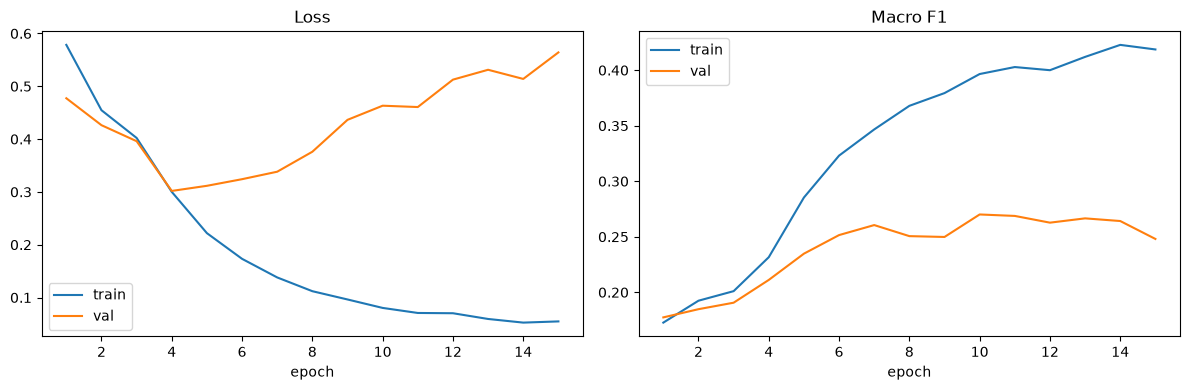

In [13]:
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history_df["epoch"], history_df["train_f1"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_f1"], label="val")
axes[1].set_title("Macro F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Evaluation

Per-rule precision/recall/F1 on the held-out test split, loading the best
checkpoint saved during training (not just whatever's left in `model`
after the last epoch, in case that epoch wasn't the best one).

In [14]:
from sklearn.metrics import classification_report

eval_model = build_model(CFG["backbone"], num_classes=len(RULE_CLASSES), pretrained=False)
ckpt = torch.load(best_ckpt_path, map_location=device)
eval_model.load_state_dict(ckpt["model_state"])
eval_model = eval_model.to(device)
eval_model.eval()

all_logits, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = eval_model(images)
        all_logits.append(logits.cpu())
        all_labels.append(labels)

if all_logits:
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    preds = (torch.sigmoid(logits) >= CFG["pred_threshold"]).float()

    print(classification_report(
        labels.numpy(), preds.numpy(), target_names=RULE_CLASSES, zero_division=0,
    ))
else:
    print("Test split produced no crops - nothing to evaluate "
          "(expected in LOCAL_MODE with a very small local_smoke_n).")


C:\Users\Lab\AppData\Local\Temp\ipykernel_26556\1114173900.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt_path, map_location=device)


              precision    recall  f1-score   support

         R09       0.00      0.00      0.00         0
         R04       0.38      0.56      0.45        45
         R17       0.44      0.58      0.50       660
         R10       0.00      0.00      0.00         0
         R28       0.00      0.00      0.00         0
         R08       0.69      0.78      0.73      1805

   micro avg       0.61      0.72      0.66      2510
   macro avg       0.25      0.32      0.28      2510
weighted avg       0.62      0.72      0.66      2510
 samples avg       0.30      0.31      0.30      2510



### Sample predictions

A quick visual spot-check: 12 test crops with ground-truth vs predicted
rule labels. Useful for catching systematic mistakes (e.g. a backbone that
always predicts "clean") that a single macro-F1 number can hide.

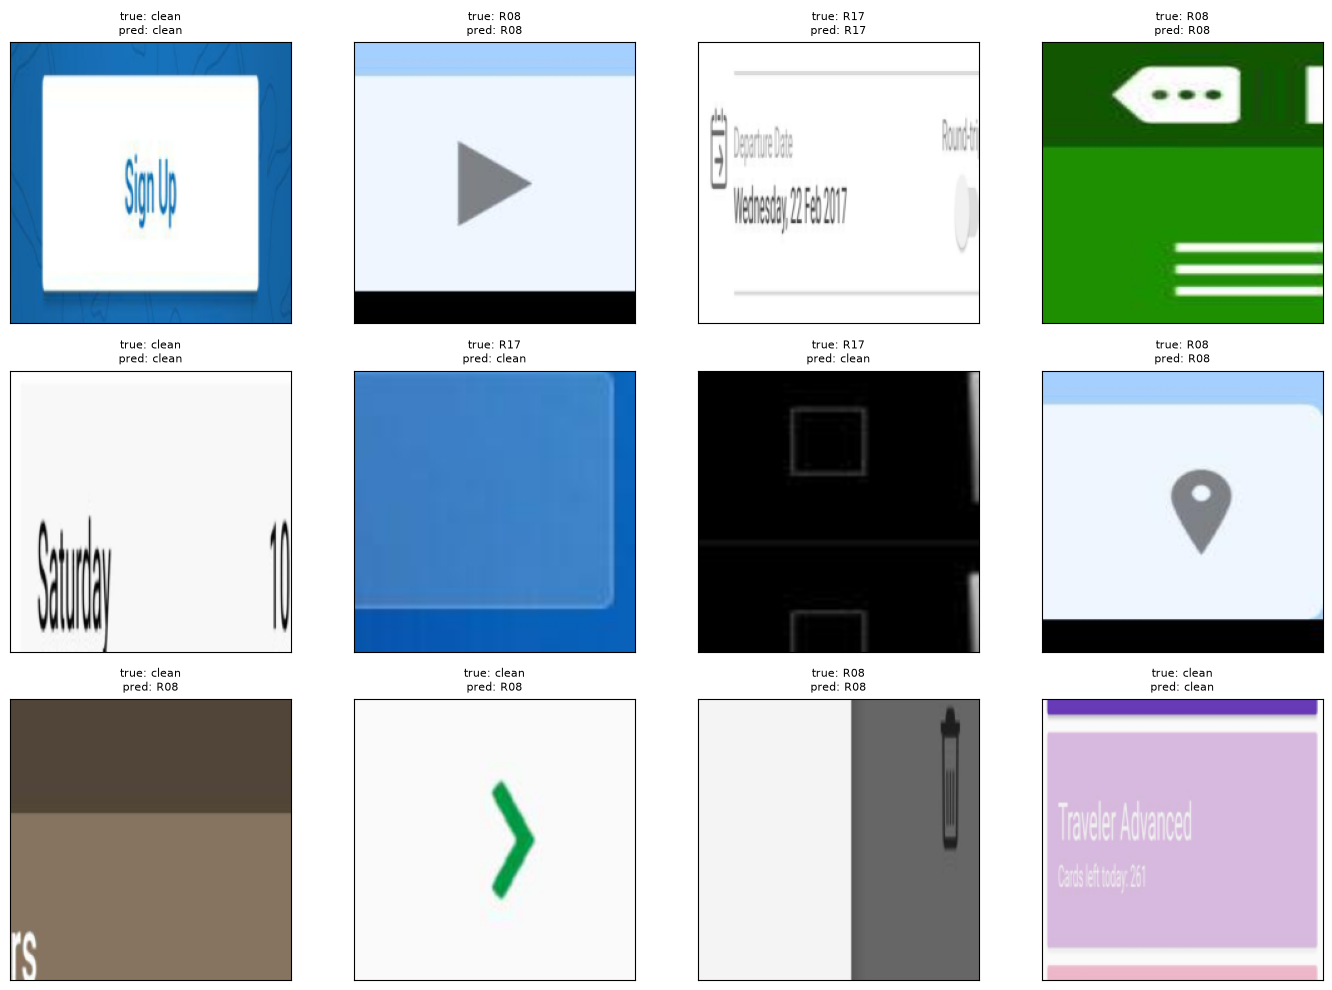

In [15]:
if len(test_manifest):
    sample_n = min(12, len(test_manifest))
    sample_idx = test_manifest.sample(n=sample_n, random_state=CFG["seed"]).index

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for ax, idx in zip(axes.flat, sample_idx):
        row = test_manifest.loc[idx]
        img = Image.open(CFG["output_root"] / row["crop_path"]).convert("RGB")
        with torch.no_grad():
            tensor = eval_transform(img).unsqueeze(0).to(device)
            pred = (torch.sigmoid(eval_model(tensor)) >= CFG["pred_threshold"]).cpu().numpy()[0]

        true_rules = [r for r in RULE_CLASSES if row[r] == 1]
        pred_rules = [r for r, p in zip(RULE_CLASSES, pred) if p]
        ax.imshow(img)
        ax.set_title(f"true: {', '.join(true_rules) or 'clean'}\npred: {', '.join(pred_rules) or 'clean'}",
                     fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes.flat[sample_n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Test split is empty - skipping sample-prediction visualization.")


## 8. Export

Copies the best checkpoint into a stable export location plus the repo's
`models/` dir, and writes a small importable inference module
(`src/crop_violation_classifier.py`), mirroring how the YOLO notebook
exports `src/yolo_ui_detector.py`.

In [16]:
CFG["export_dir"].mkdir(parents=True, exist_ok=True)
export_ckpt_path = CFG["export_dir"] / "crop_violation_classifier_best.pt"
shutil.copy2(best_ckpt_path, export_ckpt_path)
print(f"Copied best checkpoint to {export_ckpt_path}")

repo_models_dir = CFG["repo_root"] / "models"
repo_models_dir.mkdir(parents=True, exist_ok=True)
repo_ckpt_path = repo_models_dir / "crop_violation_classifier_best.pt"
shutil.copy2(best_ckpt_path, repo_ckpt_path)
print(f"Copied best checkpoint to {repo_ckpt_path}")

TQ = chr(34) * 3  # placeholder trick: avoids a literal triple-quote inside this cell's own triple-quoted source

module_source = '''<<<TQ>>>TQ>>>Crop-level accessibility-violation classifier.

Generated by notebooks/train_crop_violation_classifier.ipynb. Given a
cropped region of a screenshot, predicts which of R09 (low contrast), R04
(small touch target), R17 (insufficient spacing), R10 (text overflow),
R28 (font-scale overflow) and R08 (layout overlap) it violates - the rules
identified in docs/user_coverage_for_training.md as needing pixel-level
confirmation beyond what the XML rule checker (src/rules.py) can see.

Every one of the 33 backbones from docs/picking_model_for_crop.md's
comparison sweep gets its own explicit branch below (no dict lookup, no
generic timm fallback) so it's unambiguous which backbone maps to which
constructor call.
<<<TQ>>>
from __future__ import annotations

from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.models import (
    DenseNet121_Weights,
    ConvNeXt_Tiny_Weights,
    EfficientNet_B0_Weights,
    EfficientNet_V2_S_Weights,
    MNASNet1_0_Weights,
    MobileNet_V3_Large_Weights,
    MobileNet_V3_Small_Weights,
    RegNet_Y_800MF_Weights,
    ResNet50_Weights,
    ShuffleNet_V2_X1_0_Weights,
    SqueezeNet1_1_Weights,
    ViT_B_16_Weights,
    densenet121,
    convnext_tiny,
    efficientnet_b0,
    efficientnet_v2_s,
    mnasnet1_0,
    mobilenet_v3_large,
    mobilenet_v3_small,
    regnet_y_800mf,
    resnet50,
    shufflenet_v2_x1_0,
    squeezenet1_1,
    vit_b_16,
)

try:
    import timm
except ImportError:
    timm = None


DEFAULT_WEIGHTS = Path(__file__).resolve().parents[1] / "models" / "crop_violation_classifier_best.pt"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

_model_cache: dict[str, tuple] = {}


def _build_backbone(name: str, num_classes: int):
    if name == "mobilenet_v3_small":
        model = mobilenet_v3_small(weights=None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif name == "mobilenet_v3_large":
        model = mobilenet_v3_large(weights=None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif name == "efficientnet_b0":
        model = efficientnet_b0(weights=None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif name == "efficientnet_v2_s":
        model = efficientnet_v2_s(weights=None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif name == "mnasnet1_0":
        model = mnasnet1_0(weights=None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif name == "resnet50":
        model = resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "shufflenet_v2_x1_0":
        model = shufflenet_v2_x1_0(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "regnet_y_800mf":
        model = regnet_y_800mf(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "densenet121":
        model = densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "squeezenet1_1":
        model = squeezenet1_1(weights=None)
        model.classifier[1] = nn.Conv2d(model.classifier[1].in_channels, num_classes, kernel_size=1)
    elif name == "vit_b_16":
        model = vit_b_16(weights=None)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif name == "mobilevit_s":
        if timm is None:
            raise ImportError("mobilevit_s requires `timm` (pip install timm)")
        model = timm.create_model("mobilevit_s", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv1_100":
        if timm is None:
            raise ImportError("mobilenetv1_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv1_100", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv1_125":
        if timm is None:
            raise ImportError("mobilenetv1_125 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv1_125", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv2_050":
        if timm is None:
            raise ImportError("mobilenetv2_050 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv2_050", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv2_100":
        if timm is None:
            raise ImportError("mobilenetv2_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv2_100", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv2_140":
        if timm is None:
            raise ImportError("mobilenetv2_140 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv2_140", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv3_small_050":
        if timm is None:
            raise ImportError("mobilenetv3_small_050 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv3_small_050", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv3_small_100":
        if timm is None:
            raise ImportError("mobilenetv3_small_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv3_small_100", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv3_large_100":
        if timm is None:
            raise ImportError("mobilenetv3_large_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv3_large_100", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv4_conv_small":
        if timm is None:
            raise ImportError("mobilenetv4_conv_small requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv4_conv_small", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv4_conv_medium":
        if timm is None:
            raise ImportError("mobilenetv4_conv_medium requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv4_conv_medium", pretrained=False, num_classes=num_classes)
    elif name == "mobilenetv4_conv_large":
        if timm is None:
            raise ImportError("mobilenetv4_conv_large requires `timm` (pip install timm)")
        model = timm.create_model("mobilenetv4_conv_large", pretrained=False, num_classes=num_classes)
    elif name == "mobilevit_xxs":
        if timm is None:
            raise ImportError("mobilevit_xxs requires `timm` (pip install timm)")
        model = timm.create_model("mobilevit_xxs", pretrained=False, num_classes=num_classes)
    elif name == "mobilevit_xs":
        if timm is None:
            raise ImportError("mobilevit_xs requires `timm` (pip install timm)")
        model = timm.create_model("mobilevit_xs", pretrained=False, num_classes=num_classes)
    elif name == "mobilevitv2_050":
        if timm is None:
            raise ImportError("mobilevitv2_050 requires `timm` (pip install timm)")
        model = timm.create_model("mobilevitv2_050", pretrained=False, num_classes=num_classes)
    elif name == "mobilevitv2_100":
        if timm is None:
            raise ImportError("mobilevitv2_100 requires `timm` (pip install timm)")
        model = timm.create_model("mobilevitv2_100", pretrained=False, num_classes=num_classes)
    elif name == "mobilevitv2_200":
        if timm is None:
            raise ImportError("mobilevitv2_200 requires `timm` (pip install timm)")
        model = timm.create_model("mobilevitv2_200", pretrained=False, num_classes=num_classes)
    elif name == "mobileone_s0":
        if timm is None:
            raise ImportError("mobileone_s0 requires `timm` (pip install timm)")
        model = timm.create_model("mobileone_s0", pretrained=False, num_classes=num_classes)
    elif name == "mobileone_s1":
        if timm is None:
            raise ImportError("mobileone_s1 requires `timm` (pip install timm)")
        model = timm.create_model("mobileone_s1", pretrained=False, num_classes=num_classes)
    elif name == "mobileone_s4":
        if timm is None:
            raise ImportError("mobileone_s4 requires `timm` (pip install timm)")
        model = timm.create_model("mobileone_s4", pretrained=False, num_classes=num_classes)
    elif name == "ghostnet_100":
        if timm is None:
            raise ImportError("ghostnet_100 requires `timm` (pip install timm)")
        model = timm.create_model("ghostnet_100", pretrained=False, num_classes=num_classes)
    elif name == "ghostnetv2_100":
        if timm is None:
            raise ImportError("ghostnetv2_100 requires `timm` (pip install timm)")
        model = timm.create_model("ghostnetv2_100", pretrained=False, num_classes=num_classes)
    elif name == "convnext_tiny":
        model = convnext_tiny(weights=None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif name == "swin_tiny_patch4_window7_224":
        if timm is None:
            raise ImportError("swin_tiny_patch4_window7_224 requires `timm` (pip install timm)")
        model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=num_classes)
    else:
        raise ValueError(f"Unknown backbone: {name!r}")
    return model


def _get_model(weights_path: str | Path):
    key = str(weights_path)
    if key not in _model_cache:
        ckpt = torch.load(key, map_location="cpu")
        rule_classes = ckpt["rule_classes"]
        model = _build_backbone(ckpt["backbone"], num_classes=len(rule_classes))
        model.load_state_dict(ckpt["model_state"])
        model.eval()
        transform = transforms.Compose([
            transforms.Resize((ckpt["crop_size"], ckpt["crop_size"])),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
        _model_cache[key] = (model, transform, rule_classes)
    return _model_cache[key]


def classify_crop(
    image_path: str | Path,
    bounds: list[int] | None = None,
    weights_path: str | Path = DEFAULT_WEIGHTS,
    threshold: float = 0.5,
) -> dict[str, float]:
    <<<TQ>>>Classify one crop (or one region of a larger screenshot).

    If bounds=[left, top, right, bottom] is given, that region is cropped
    out of the image first; otherwise the whole image is treated as the
    crop. Returns {rule_id: probability} for every rule the model predicts
    above `threshold`, plus every rule's raw probability under "_all".
    <<<TQ>>>
    model, transform, rule_classes = _get_model(weights_path)
    img = Image.open(image_path).convert("RGB")
    if bounds is not None:
        img = img.crop(tuple(bounds))

    with torch.no_grad():
        tensor = transform(img).unsqueeze(0)
        probs = torch.sigmoid(model(tensor))[0].tolist()

    result = {"_all": dict(zip(rule_classes, probs))}
    for rule, prob in zip(rule_classes, probs):
        if prob >= threshold:
            result[rule] = prob
    return result


CV_CONFIRMABLE_RULES = {"R08", "R17", "R04"}


def confirm_violations(violations_doc: dict, screenshot_path: str | Path) -> dict:
    <<<TQ>>>Attach a pixel-level cv_confidence to violations whose rule has real
    CV training signal. Mutates and returns violations_doc in place.

    Additive only, per FR-CV.2: never removes a violation or changes its
    severity based on the CV result. A CV failure (corrupt image, model
    load issue) never raises - it just leaves cv_confidence as None, since
    this is a supplementary signal and must not break the underlying,
    already-valid XML-based audit.
    <<<TQ>>>
    for violation in violations_doc.get("violations", []):
        if violation["rule_id"] not in CV_CONFIRMABLE_RULES:
            continue
        try:
            result = classify_crop(screenshot_path, bounds=violation["bounds"])
            violation["cv_confidence"] = round(result["_all"][violation["rule_id"]], 4)
        except Exception:
            violation["cv_confidence"] = None
    return violations_doc
'''
module_source = module_source.replace("<<<TQ>>>", TQ)

module_path = CFG["repo_root"] / "src" / "crop_violation_classifier.py"
module_path.write_text(module_source, encoding="utf-8")
print(f"Wrote {module_path}")
print()
print("Done. classify_crop() is importable from src.crop_violation_classifier "
      "once models/crop_violation_classifier_best.pt is present.")


Copied best checkpoint to C:\Users\Lab\agentic-accessibility-auditor\runs\crop_violation_classifier\export\crop_violation_classifier_best.pt
Copied best checkpoint to C:\Users\Lab\agentic-accessibility-auditor\models\crop_violation_classifier_best.pt
Wrote C:\Users\Lab\agentic-accessibility-auditor\src\crop_violation_classifier.py

Done. classify_crop() is importable from src.crop_violation_classifier once models/crop_violation_classifier_best.pt is present.


## 9. Rico holdout evaluation (generalization check)

`data-rico-holdout` was **never used for training or validation** above - this
section runs the already-trained checkpoint (`eval_model`, loaded in §7) against
1,698 Rico screens to check whether the model generalizes to apps it has never
seen, the same way `notebooks/train_yolo_ui_detector.ipynb` cross-checks its
detector against the same holdout set. No training happens here - this only
builds a Rico crop set (reusing the rule checker for labels, same as §1-2) and
runs inference.

In [17]:
if "eval_model" not in globals():
    raise RuntimeError(
        "eval_model is not defined - run the Evaluation section (§7) above first, "
        "so the best checkpoint is loaded."
    )

CFG["rico_root"] = DATA_ROOT / "data-rico-holdout"
CFG["rico_crop_dir"] = CFG["output_root"] / "rico_crops"
CFG["rico_manifest_dir"] = CFG["output_root"] / "rico_manifest"

rico_checks = {
    "data-rico-holdout/screenshots": CFG["rico_root"] / "screenshots",
    "data-rico-holdout/xml": CFG["rico_root"] / "xml",
    "data-rico-holdout/manifest/screens.csv": CFG["rico_root"] / "manifest" / "screens.csv",
}

rico_available = True
for label, path in rico_checks.items():
    exists = path.exists()
    rico_available &= exists
    print(f"[{'OK' if exists else 'MISSING'}] {label} -> {path}")

if rico_available:
    with open(CFG["rico_root"] / "manifest" / "screens.csv", newline="", encoding="utf-8") as f:
        rico_rows = list(csv.DictReader(f))
    print(f"\nrico manifest: {len(rico_rows)} screens")
else:
    print("\nSkipping Rico holdout evaluation: screenshots/xml/manifest not found under data-rico-holdout.")


[OK] data-rico-holdout/screenshots -> C:\Users\Lab\agentic-accessibility-auditor\data\data-rico-holdout\screenshots
[OK] data-rico-holdout/xml -> C:\Users\Lab\agentic-accessibility-auditor\data\data-rico-holdout\xml
[OK] data-rico-holdout/manifest/screens.csv -> C:\Users\Lab\agentic-accessibility-auditor\data\data-rico-holdout\manifest\screens.csv

rico manifest: 1698 screens


In [18]:
def extract_screen_records_rico(xml_path, image_path, rng):
    """Same crop-extraction logic as extract_screen_records() (see §2), but
    rooted at CFG["rico_root"] instead of CFG["masc_root"]. Kept as a separate
    copy rather than parameterizing the original, so the already-shipped MASC
    training pipeline above is never touched by this evaluation-only addition.
    """
    doc = build_screen_document(xml_path, CFG["rico_root"] / "xml", CFG["rico_root"])
    components = [c for c in doc["components"] if c.get("visible", True)]
    if not components:
        return []

    device_info = doc["device_info"]
    with Image.open(image_path) as im:
        img_w, img_h = im.size

    xml_w, xml_h = _xml_canvas_size(device_info, components)
    if xml_w <= 0 or xml_h <= 0:
        return []
    scale_x, scale_y = img_w / xml_w, img_h / xml_h

    hits = target_violations_by_component(doc)
    comps_by_id = {c["component_id"]: c for c in components}

    records = []
    for comp_id, rules_hit in hits.items():
        comp = comps_by_id.get(comp_id)
        if comp is None:
            continue
        box = _scaled_padded_box(
            comp["bounds"], scale_x, scale_y, img_w, img_h,
            CFG["context_pad_frac"], CFG["min_crop_px"],
        )
        if box is None:
            continue
        label = [1 if r in rules_hit else 0 for r in RULE_CLASSES]
        records.append({
            "component_id": comp_id, "bounds": box, "label": label,
            "class": comp["class"], "is_positive": True,
        })

    candidates = [
        c for c in components
        if c["component_id"] not in hits and (c["clickable"] or c["text"])
    ]
    rng.shuffle(candidates)
    n_neg = 0
    for comp in candidates:
        if n_neg >= CFG["negatives_per_screen"]:
            break
        box = _scaled_padded_box(
            comp["bounds"], scale_x, scale_y, img_w, img_h,
            CFG["context_pad_frac"], CFG["min_crop_px"],
        )
        if box is None:
            continue
        records.append({
            "component_id": comp["component_id"], "bounds": box,
            "label": [0] * len(RULE_CLASSES), "class": comp["class"],
            "is_positive": False,
        })
        n_neg += 1

    return records


print("Loaded extract_screen_records_rico().")


Loaded extract_screen_records_rico().


In [19]:
if rico_available:
    for d in (CFG["rico_crop_dir"], CFG["rico_manifest_dir"]):
        if d.exists():
            shutil.rmtree(d)
        d.mkdir(parents=True, exist_ok=True)

    rico_crop_subdir = CFG["rico_crop_dir"] / "holdout"
    rico_crop_subdir.mkdir(parents=True, exist_ok=True)

    rng = random.Random(CFG["seed"])
    rico_manifest_rows = []
    rico_label_counts = Counter()
    n_positive_crops = 0
    n_negative_crops = 0
    n_screens_skipped = 0

    rows_to_process = rico_rows[: CFG["local_smoke_n"]] if CFG["local_mode"] else rico_rows

    for row in rows_to_process:
        xml_path = CFG["repo_root"] / row["xml_path"]
        image_path = CFG["repo_root"] / row["screenshots_path"]
        if not xml_path.exists() or not image_path.exists():
            n_screens_skipped += 1
            continue

        try:
            records = extract_screen_records_rico(xml_path, image_path, rng)
        except Exception as exc:
            print(f"[skip] {row['screen_id']} ({row['category']}): {exc}")
            n_screens_skipped += 1
            continue

        if not records:
            continue

        with Image.open(image_path) as im:
            im = im.convert("RGB")
            for rec in records:
                crop = im.crop(rec["bounds"]).resize(
                    (CFG["crop_size"], CFG["crop_size"]), Image.BILINEAR
                )
                crop_name = f"{row['category']}_{row['screen_id']}_{rec['component_id']}.png"
                crop_path = rico_crop_subdir / crop_name
                crop.save(crop_path)

                rico_manifest_rows.append({
                    "crop_path": str(crop_path.relative_to(CFG["output_root"])),
                    "screen_id": row["screen_id"], "category": row["category"],
                    "component_id": rec["component_id"], "class": rec["class"],
                    "is_positive": rec["is_positive"],
                    **{rule: label_val for rule, label_val in zip(RULE_CLASSES, rec["label"])},
                })
                if rec["is_positive"]:
                    n_positive_crops += 1
                    for rule, label_val in zip(RULE_CLASSES, rec["label"]):
                        if label_val:
                            rico_label_counts[rule] += 1
                else:
                    n_negative_crops += 1

    rico_manifest_path = CFG["rico_manifest_dir"] / "holdout.csv"
    with open(rico_manifest_path, "w", newline="", encoding="utf-8") as f:
        fieldnames = ["crop_path", "screen_id", "category", "component_id", "class", "is_positive", *RULE_CLASSES]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rico_manifest_rows)

    print(f"[rico holdout] {len(rico_manifest_rows)} crops from "
          f"{len(rows_to_process) - n_screens_skipped}/{len(rows_to_process)} screens "
          f"({n_positive_crops} positive, {n_negative_crops} negative) -> {rico_manifest_path}")
    print(f"                per-rule positive counts: {dict(rico_label_counts)}")
else:
    print("Skipping Rico crop build: data-rico-holdout not available.")


[rico holdout] 9343 crops from 1698/1698 screens (4502 positive, 4841 negative) -> C:\Users\Lab\agentic-accessibility-auditor\runs\crop_violation_classifier\rico_manifest\holdout.csv
                per-rule positive counts: {'R17': 1419, 'R08': 3418, 'R04': 145}


In [20]:
if rico_available and len(rico_manifest_rows):
    rico_manifest = pd.read_csv(rico_manifest_path)
    rico_ds = CropViolationDataset(rico_manifest, RULE_CLASSES, CFG["output_root"], eval_transform)
    rico_loader = DataLoader(rico_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=0)

    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in rico_loader:
            images = images.to(device)
            logits = eval_model(images)
            all_logits.append(logits.cpu())
            all_labels.append(labels)

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    preds = (torch.sigmoid(logits) >= CFG["pred_threshold"]).float()

    print(f"Rico holdout crops evaluated: {len(rico_ds)}")
    print()
    print(classification_report(
        labels.numpy(), preds.numpy(), target_names=RULE_CLASSES, zero_division=0,
    ))
    print()
    print("Compare against the MASC test-split report in §7 above - a large drop here")
    print("means the model memorized MASC's visual style rather than the general rule")
    print("signal; a similar report means real generalization to unseen apps.")
else:
    print("Skipping Rico evaluation: no crops were built (see previous cell).")


Rico holdout crops evaluated: 9343

              precision    recall  f1-score   support

         R09       0.00      0.00      0.00         0
         R04       0.39      0.46      0.42       145
         R17       0.31      0.36      0.33      1419
         R10       0.00      0.00      0.00         0
         R28       0.00      0.00      0.00         0
         R08       0.53      0.45      0.49      3418

   micro avg       0.45      0.43      0.44      4982
   macro avg       0.21      0.21      0.21      4982
weighted avg       0.46      0.43      0.44      4982
 samples avg       0.21      0.21      0.20      4982


Compare against the MASC test-split report in §7 above - a large drop here
means the model memorized MASC's visual style rather than the general rule
signal; a similar report means real generalization to unseen apps.


### Sample Rico predictions

Same spot-check as §7's "Sample predictions", but on Rico crops the model
never saw during training or the original MASC test evaluation.

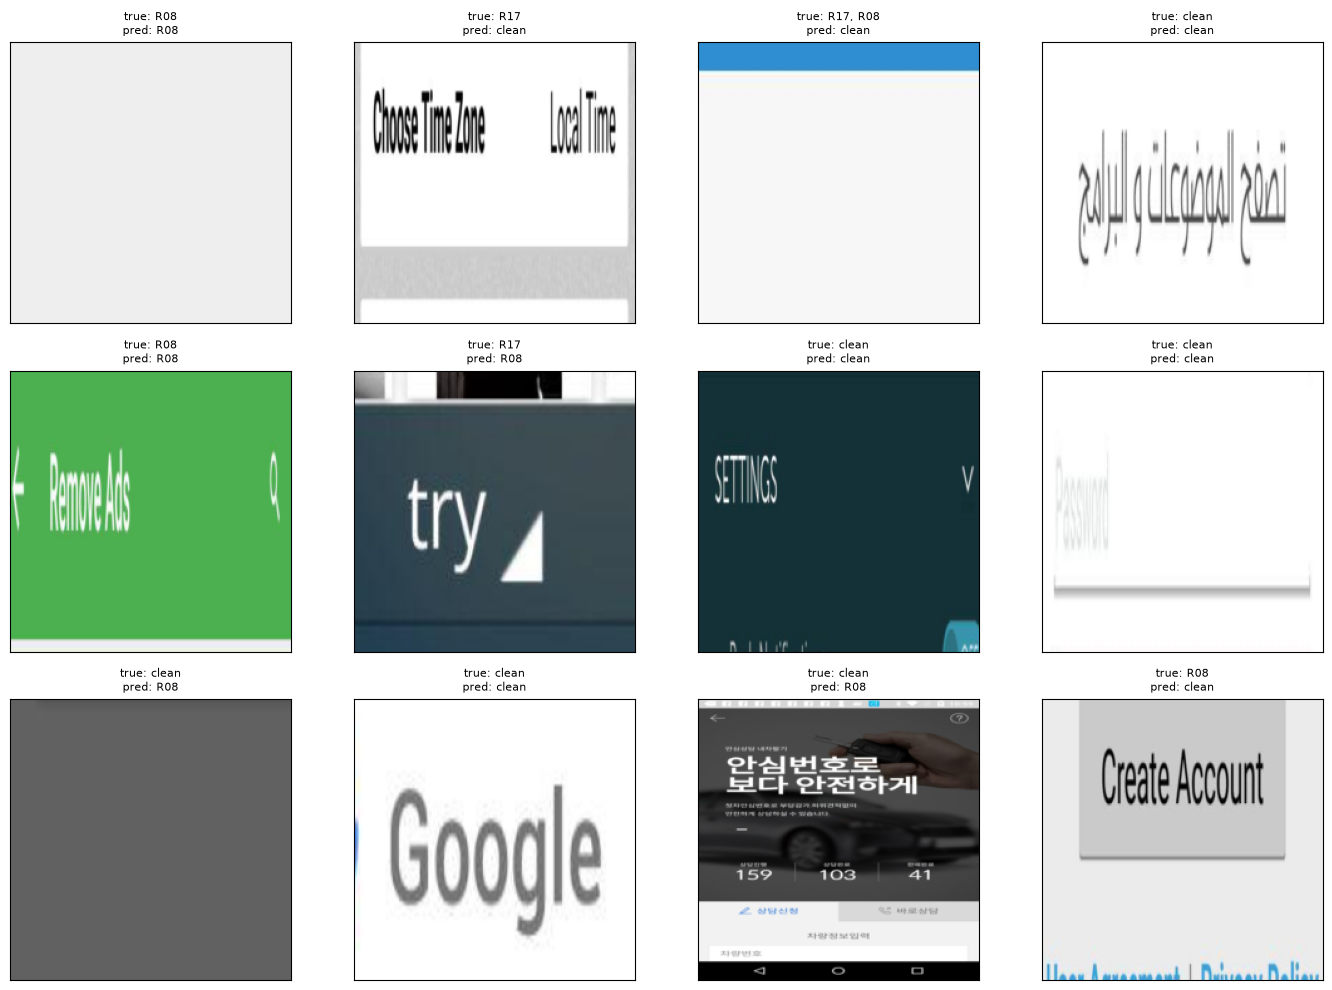

In [21]:
if rico_available and len(rico_manifest_rows):
    sample_n = min(12, len(rico_manifest))
    sample_idx = rico_manifest.sample(n=sample_n, random_state=CFG["seed"]).index

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for ax, idx in zip(axes.flat, sample_idx):
        row = rico_manifest.loc[idx]
        img = Image.open(CFG["output_root"] / row["crop_path"]).convert("RGB")
        with torch.no_grad():
            tensor = eval_transform(img).unsqueeze(0).to(device)
            pred = (torch.sigmoid(eval_model(tensor)) >= CFG["pred_threshold"]).cpu().numpy()[0]

        true_rules = [r for r in RULE_CLASSES if row[r] == 1]
        pred_rules = [r for r, p in zip(RULE_CLASSES, pred) if p]
        ax.imshow(img)
        ax.set_title(f"true: {', '.join(true_rules) or 'clean'}\npred: {', '.join(pred_rules) or 'clean'}",
                     fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes.flat[sample_n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Rico manifest empty - skipping sample-prediction visualization.")


## Next steps

- Flip `LOCAL_MODE = False` and re-run from the **Config** cell for the
  real training run on the full `data-masc` split (not just
  `local_smoke_n` screens).
- **Backbone choice is no longer purely theoretical** - `docs/crop_classifier_comparison_findings.md`
  has real MASC + Rico-holdout results across 33 backbones. Notably: `resnet50` (the doc's fallback
  escalation) turned out unremarkable, and `vit_b_16`/`mobilevitv2_200` (both flagged as risky a priori)
  actually tied for the best generalization result in the whole sweep - driven by a real, reproducible
  attention-specific effect (confirmed via a `convnext_tiny` control: same size, no attention, normal
  result). Read that doc before assuming the original a priori guidance below still holds.
- Element *detection* on screenshots (locating UI elements in the first
  place) stays on **YOLO** (`notebooks/train_yolo_ui_detector.ipynb`) -
  this notebook only classifies a crop once a UI element's bounds are
  already known (from the XML parser today, or from the YOLO detector on
  screenshot-only screens).
- ~~Consider evaluating on `data-rico-holdout`~~ **Done — see §9** above.
  Run §9's cells after §7 to build the Rico crop set and get a real
  generalization report; not yet wired into `backend/` (see
  `docs/progress/Supplementary_Progress_Report_v1.24.md` §15H).
